# Module 3 — Appendiceal Cancer: Patient Population

**Prerequisite:** Run `01_appendiceal_explore.ipynb` first to create the `appendiceal_reports` table.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [12]:
ages_of_appendiceal = pd.read_sql_query("""
SELECT DISTINCT ac.primaryid, d.age
FROM appendiceal_cohort ac
JOIN demo d ON ac.primaryid = d.primaryid
                                       

""", conn)


ages_of_appendiceal.head(5)

,primaryid,age
0,222632612,81.0
1,222887352,40.0
2,2279943113,69.0
3,233424642,65.0
4,233797203,68.0


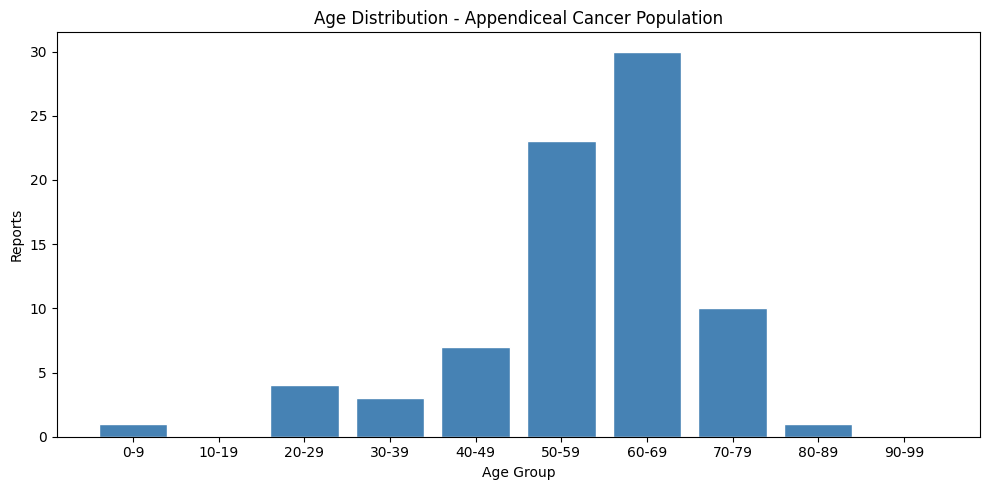

In [13]:
import matplotlib.pyplot as plt

# Convert age to numeric — FAERS stores age as string, coerce invalid values to NaN
ages_of_appendiceal['age'] = pd.to_numeric(ages_of_appendiceal['age'], errors='coerce')

# Drop missing ages
ages_clean = ages_of_appendiceal.dropna(subset=['age'])

# Bin into 10-year buckets
ages_clean = ages_clean.copy()
ages_clean['age_group'] = pd.cut(
    ages_clean['age'],
    bins=range(0, 101, 10),
    right=False,
    labels=[f'{i}-{i+9}' for i in range(0, 100, 10)]
)

# Count patients per age group
age_counts = ages_clean['age_group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(age_counts.index.astype(str), age_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Age Group')
ax.set_ylabel('Reports')
ax.set_title('Age Distribution - Appendiceal Cancer Population')
plt.tight_layout()
plt.show()


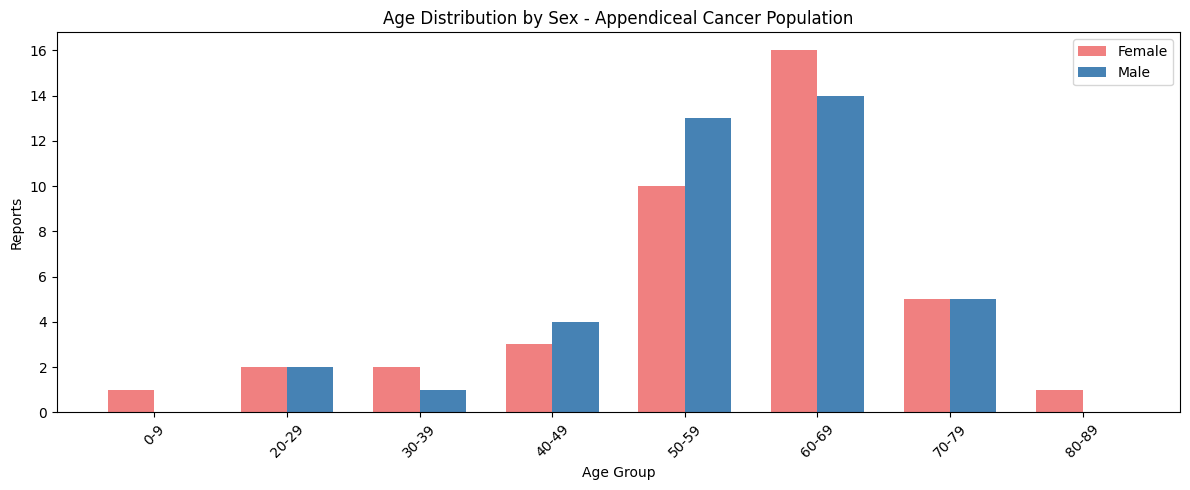

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Pull age and sex together from demo, joined to appendiceal cohort
age_sex = pd.read_sql_query("""
    SELECT DISTINCT ac.primaryid, d.age, d.sex
    FROM appendiceal_cohort ac
    JOIN demo d ON ac.primaryid = d.primaryid
    WHERE d.sex IN ('M', 'F')
      AND d.age IS NOT NULL
""", conn)

# Convert age to numeric and drop invalid values
age_sex['age'] = pd.to_numeric(age_sex['age'], errors='coerce')
age_sex = age_sex.dropna(subset=['age'])

# Bin into 10-year age groups
bins = range(0, 101, 10)
labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
age_sex['age_group'] = pd.cut(age_sex['age'], bins=bins, right=False, labels=labels)

# Count by age group and sex
age_sex_counts = age_sex.groupby(['age_group', 'sex'], observed=True).size().unstack(fill_value=0)

# Plot grouped bar chart
x = np.arange(len(age_sex_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, age_sex_counts.get('F', 0), width, label='Female', color='lightcoral')
ax.bar(x + width/2, age_sex_counts.get('M', 0), width, label='Male',   color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(age_sex_counts.index.astype(str), rotation=45)
ax.set_xlabel('Age Group')
ax.set_ylabel('Reports')
ax.set_title('Age Distribution by Sex - Appendiceal Cancer Population')
ax.legend()
plt.tight_layout()
plt.show()


The 50-69 age range dominates reports as expected for a GI malignancy. 
Interestingly the male and female counts are fairly close across most age groups — 
appendiceal cancer is one of the few GI cancers that doesn't show a strong sex skew, 
which tracks with what's reported in the clinical literature.


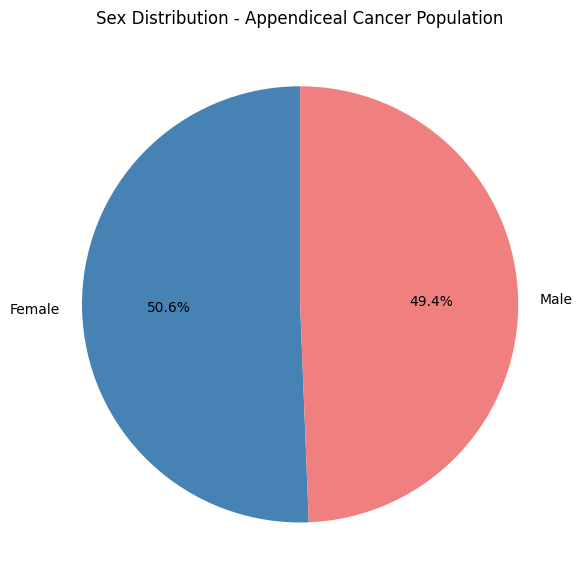

In [15]:
# Sex breakdown pie chart
sex_counts = age_sex['sex'].value_counts()
sex_labels = {'M': 'Male', 'F': 'Female', 'U': 'Unknown'}
labels = [sex_labels.get(s, s) for s in sex_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sex_counts.values, labels=labels, autopct='%1.1f%%',
       colors=['steelblue', 'lightcoral'], startangle=90)
ax.set_title('Sex Distribution - Appendiceal Cancer Population')
plt.tight_layout()
plt.show()


Roughly even M/F split with a slight male lean. This is somewhat inconsistent with 
the epidemiology. Appendiceal mucinous tumors in particular tend to present 
slightly more often in women, which is related to the overlap with ovarian 
pseudomyxoma peritonei spread patterns.


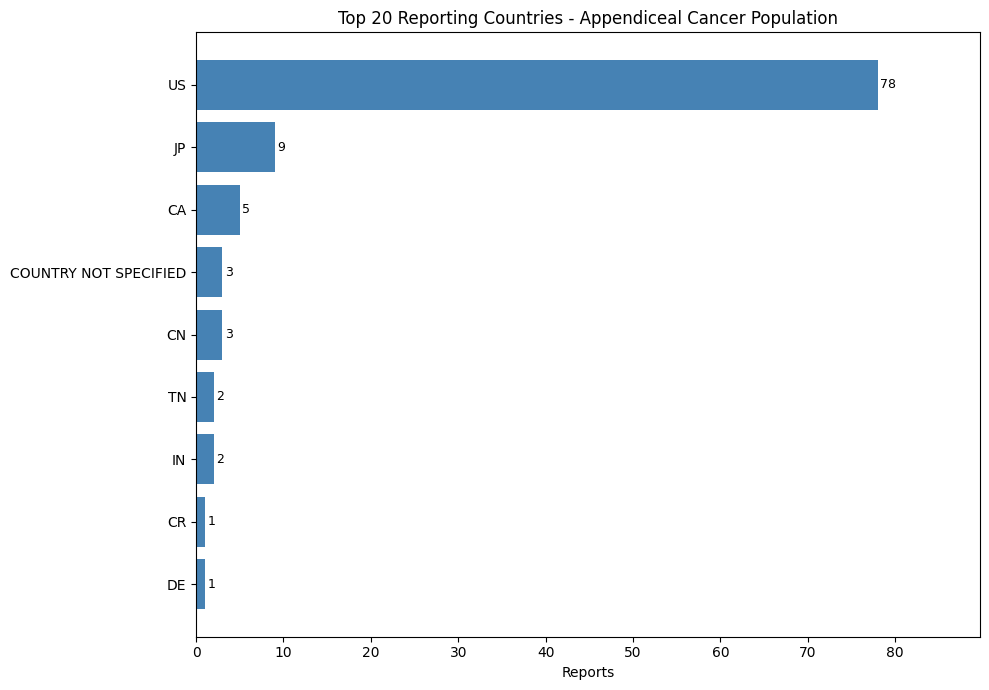

In [16]:
# Top 20 reporting countries for appendiceal cancer population
country_counts = pd.read_sql_query("""
    SELECT DISTINCT ac.primaryid, d.reporter_country
    FROM appendiceal_cohort ac
    JOIN demo d ON ac.primaryid = d.primaryid
    WHERE d.reporter_country IS NOT NULL
""", conn)

top_countries = (
    country_counts['reporter_country']
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_countries.index, top_countries.values, color='steelblue')

# Add count labels to the end of each bar
for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Reports')
ax.set_title('Top 20 Reporting Countries - Appendiceal Cancer Population')
ax.set_xlim(0, top_countries.values.max() * 1.15)
plt.tight_layout()
plt.show()


US dominates as expected.

FAERS is an FDA database so domestic reporting 
makes up the bulk of submissions. The presence of several European countries 
and Canada suggests appendiceal cancer is being recognized and reported 
internationally, though the counts are small enough that any country-level 
conclusions would be a stretch.
